# SGI-4.13 — What holds philosophy together?

**Marvel Superstars**, week 4 (exercise 4.13, "Go nuts with your LLM"). This week the shared network is the
philosophers: everyone born before 1900 on Wikipedia's lists of philosophers, linked when one article links to
another, with a weight that counts how often.

**The question.** Philosophy falls into traditions: antiquity, the scholastics, German idealism, Indian and
Chinese thought. What holds those traditions together? Each section answers the question the previous one raises:

| § | the question | week-4 tools |
|---|---|---|
| 2 | Are there traditions at all? | community, modularity $Q$, Louvain, $Q$ of a random network (greedy merging for comparison) |
| 3 | Where do they meet? | edge betweenness, Girvan–Newman |
| 4 | How sure are we of the borders? | Louvain's seeds, NMI |
| 5 | What are the meeting links made of? | weight, strength, weighted distance, weighted modularity |
| 6 | Who stands where traditions meet? | overlapping communities: $k$-cliques, link communities |
| 7 | Can a drawing show the meeting points? | global threshold, disparity filter, the five drawing rules |
| 8 | 🔬 Are the links what we say they are? | the Wikipedia sentences behind the key links |

Figures go to `Figures/Week4/`; every number quoted in the post lands in `stats.json`.

In [1]:
import itertools
import json
import re
import sys
import time
from pathlib import Path
from urllib.parse import unquote

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import requests
from networkx.algorithms import community as nxc
from scipy.stats import spearmanr
from sklearn.metrics import normalized_mutual_info_score as nmi

DATA = Path("../../Data/Week4")
FIGDIR = Path("../../Figures/Week4")     # written straight to where the post reads them
FIGDIR.mkdir(parents=True, exist_ok=True)

# the week-4 post's own light look (this week only): white, graphite, one ultramarine accent
plt.rcParams.update({"figure.facecolor": "#FFFFFF", "axes.facecolor": "#FFFFFF", "savefig.facecolor": "#FFFFFF",
                     "axes.edgecolor": "#111316", "axes.labelcolor": "#5B6068", "text.color": "#111316",
                     "xtick.color": "#5B6068", "ytick.color": "#5B6068", "grid.color": "#E3E5E8",
                     "font.family": ["Arial", "DejaVu Sans"], "font.size": 11, "figure.dpi": 110})
UM, INK, MID, PALE = "#2438E8", "#111316", "#5B6068", "#B4B9C0"
PAL = ["#2438E8", "#E5402A", "#17A2C4", "#F2B705", "#D1307A", "#1E9E5A", "#6B3FA0", "#9A6A3A", "#8A9099"]

SEED = 0            # the Louvain run we name and draw (as in SGI-4.5)
RUN_SEEDS = range(1, 31)
ALPHA_DRAW = 0.3    # the backbone we draw; §7 says why
STATS = {}


def save(fig, name):
    fig.savefig(FIGDIR / f"{name}.png", bbox_inches="tight", dpi=200)
    print(f"  wrote Figures/Week4/{name}.png")


def style(ax, grid="y"):
    if grid:
        ax.grid(axis=grid, lw=.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


print(f"python {sys.version.split()[0]} | networkx {nx.__version__} | pandas {pd.__version__}")

python 3.14.6 | networkx 3.6.1 | pandas 3.0.3


## 1. Load: one weighted, undirected network

The edge file has $A \to B$ with weight = how many times $A$'s article links to $B$'s. As its header says, we sum
both directions into one undirected link, and keep the giant component: the network of SGI-4.5 to 4.11.

In [2]:
nodes = pd.read_csv(DATA / "week4_philosophers_nodes.tsv", sep="\t", comment="#", quoting=3).set_index("node_id")
edges = pd.read_csv(DATA / "week4_philosophers_edges.tsv", sep="\t", comment="#")
name = nodes.name

pair = pd.DataFrame(np.sort(edges[["source", "target"]].values, axis=1), columns=["u", "v"])
E = pair.assign(w=edges.weight).groupby(["u", "v"], as_index=False).w.sum()      # A->B plus B->A
G = nx.Graph()
G.add_nodes_from(nodes.index)
G.add_weighted_edges_from(E.itertuples(index=False))
giant = G.subgraph(max(nx.connected_components(G), key=len)).copy()
E = E[E.u.isin(set(giant))].reset_index(drop=True)

k = pd.Series(dict(giant.degree()))
s = pd.Series(dict(giant.degree(weight="weight")))
n, m = giant.number_of_nodes(), giant.number_of_edges()
heavy = E.loc[E.w.idxmax()]
rank_k, rank_s = k.rank(ascending=False, method="min"), s.rank(ascending=False, method="min")
STATS.update(n=n, m=m, w1=int((E.w == 1).sum()), w_max=int(E.w.max()),
             heaviest=[name[heavy.u], name[heavy.v]], rho_k_s=round(spearmanr(k, s).statistic, 2),
             diogenes=dict(k=int(k["Diogenes_Laertius"]), s=int(s["Diogenes_Laertius"]),
                           rank_k=int(rank_k["Diogenes_Laertius"]), rank_s=int(rank_s["Diogenes_Laertius"])),
             aristotle_k_s=[int(k["Aristotle"]), int(s["Aristotle"])])
print(f"  giant component: n = {n:,}, m = {m:,}; weights 1–{STATS['w_max']}, {STATS['w1']:,} of weight 1; "
      f"heaviest {' – '.join(STATS['heaviest'])} ({heavy.w})")
print(f"  Spearman(degree, strength) = {STATS['rho_k_s']}; Diogenes Laertius #{STATS['diogenes']['rank_k']} by degree, "
      f"#{STATS['diogenes']['rank_s']} by strength")
assert (n, m) == (1374, 9139)

  giant component: n = 1,374, m = 9,139; weights 1–24, 5,899 of weight 1; heaviest Erasmus – Thomas More (24)
  Spearman(degree, strength) = 0.96; Diogenes Laertius #15 by degree, #5 by strength


## 2. Are there traditions at all?

A **community** is a set of nodes more densely linked among themselves than to the rest; a **partition** puts every
node in exactly one. **Modularity** scores a partition: the fraction of links inside communities minus the fraction
expected if the links were shuffled with every degree kept,

$$Q = \sum_c \left[\frac{\ell_c}{m} - \left(\frac{d_c}{2m}\right)^2\right].$$

Louvain climbs $Q$ in two phases (move single nodes, then merge communities into super-nodes). We run it
unweighted, with seed 0, and name each community after its highest-degree member. The names are our labels, not
findings.

**Compared to what?** A random network has communities too, because an optimiser can always find borders that cross
fewer links than expected. So the reference is Louvain on 20 degree-preserving shuffles of the same network
(week 2's null), and the result is reported as a $z$-score. Greedy merging (Newman 2004) is run for comparison.

In [3]:
parts = sorted(nxc.louvain_communities(giant, weight=None, seed=SEED), key=len, reverse=True)
comm = {v: i for i, p in enumerate(parts) for v in p}
group = [f"{name[max(p, key=k.get)]} & co." for p in parts]
Q = nxc.modularity(giant, parts, weight=None)

rng = np.random.default_rng(413)                   # the shuffles' seeds; Louvain on each gets a different one
null_q = []
for sd in rng.integers(0, 2**31 - 1, 20):
    H = giant.copy()
    nx.double_edge_swap(H, nswap=10 * m, max_tries=100 * m, seed=int(sd))
    null_q.append(nxc.modularity(H, nxc.louvain_communities(H, weight=None, seed=int(sd) + 1), weight=None))
null_q = np.array(null_q)
greedy = nxc.greedy_modularity_communities(giant, weight=None)

STATS["traditions"] = dict(count=len(parts), Q=round(Q, 3), names=group, sizes=[len(p) for p in parts],
                           null_mean=round(null_q.mean(), 3), null_sd=round(null_q.std(ddof=1), 3),
                           z=round((Q - null_q.mean()) / null_q.std(ddof=1)),
                           greedy_count=len(greedy), greedy_Q=round(nxc.modularity(giant, greedy, weight=None), 3),
                           greedy_top3=sorted((len(c) for c in greedy), reverse=True)[:3])
t = STATS["traditions"]
print(f"  Louvain: {t['count']} communities, Q = {t['Q']}; shuffles Q = {t['null_mean']} ± {t['null_sd']}, z = {t['z']}")
print(f"  greedy merging: {t['greedy_count']} communities, Q = {t['greedy_Q']}, largest {t['greedy_top3']}")
pd.DataFrame({"philosophers": [len(p) for p in parts],
              "next highest-degree members": [", ".join(name[sorted(p, key=k.get, reverse=True)[1:5]]) for p in parts]},
             index=pd.Index(group, name="tradition (Louvain, seed 0)"))

  Louvain: 9 communities, Q = 0.503; shuffles Q = 0.222 ± 0.002, z = 136
  greedy merging: 15 communities, Q = 0.416, largest [550, 481, 262]


,philosophers,next highest-degree members
"tradition (Louvain, seed 0)",,
Immanuel Kant & co.,238,"Georg Wilhelm Friedrich Hegel, Friedrich Nietz..."
Thomas Aquinas & co.,215,"Augustine of Hippo, Jesus, Plotinus, Dante Ali..."
John Locke & co.,196,"David Hume, Karl Marx, Isaac Newton, Jean-Jacq..."
Aristotle & co.,191,"Plato, Cicero, Diogenes Laertius, Heraclitus"
Bertrand Russell & co.,154,"Edmund Husserl, Henri Bergson, William James, ..."
René Descartes & co.,114,"Gottfried Wilhelm Leibniz, Thomas Hobbes, Gali..."
The Buddha & co.,107,"Adi Shankara, Rabindranath Tagore, Madhvachary..."
Avicenna & co.,84,"Averroes, Maimonides, Al-Ghazali, Al-Farabi"
Confucius & co.,75,"Zhu Xi, Mao Zedong, Mencius, Laozi"


  wrote Figures/Week4/fig2_null.png


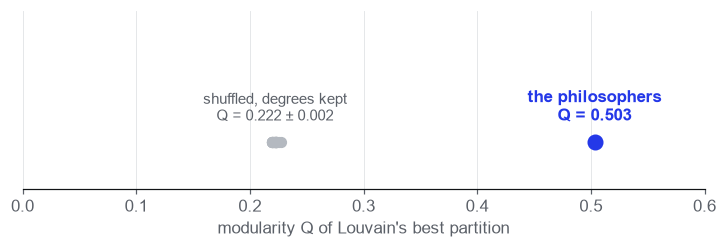

In [4]:
fig, ax = plt.subplots(figsize=(8, 2.1))
ax.scatter(null_q, np.zeros_like(null_q), s=40, color=PALE, zorder=2, label="20 shuffles")
ax.scatter([Q], [0], s=90, color=UM, zorder=3)
ax.annotate(f"the philosophers\nQ = {Q:.3f}", (Q, 0), xytext=(0, 14), textcoords="offset points", ha="center", color=UM, fontsize=11, fontweight="bold")
ax.annotate(f"shuffled, degrees kept\nQ = {null_q.mean():.3f} ± {null_q.std(ddof=1):.3f}", (null_q.mean(), 0), xytext=(0, 14),
            textcoords="offset points", ha="center", color=MID, fontsize=10)
ax.set(xlim=(0, 0.6), ylim=(-0.5, 1.4), yticks=[], xlabel="modularity Q of Louvain's best partition")
style(ax, grid="x")
ax.spines["left"].set_visible(False)
save(fig, "fig2_null")
plt.show()

**Result.** Nine traditions with $Q = 0.50$ against about $0.22$ for shuffled copies: far beyond chance. The
shuffles are not at zero, which is the point of comparing. Greedy merging finds 15 groups with a lower $Q$
(0.416), because a merge is never undone and early merges snowball into three large blobs.

## 3. Where do the traditions meet?

Girvan and Newman's idea: a link between two groups carries all the shortest paths between them, so it has a high
**edge betweenness**. Their algorithm removes the top link, recomputes, and repeats until the network falls apart.
One pass is cheap; a full run needs one pass per link. We time one pass to see why nobody runs it here, and use the
single pass to ask: are the busiest links the ones that cross between traditions?

Then a robustness check with **weighted distance**: if a strong tie is a short step (length $1/w$, shortest paths by
Dijkstra), do the busiest roads change?

In [5]:
t0 = time.time()
eb = nx.edge_betweenness_centrality(giant, normalized=False, weight=None)
eb_seconds = time.time() - t0
for u, v, d in giant.edges(data=True):
    d["length"] = 1 / d["weight"]
ebw = nx.edge_betweenness_centrality(giant, normalized=False, weight="length")

key = lambda u, v: (u, v) if (u, v) in eb else (v, u)
E["eb"] = [eb[key(u, v)] for u, v in zip(E.u, E.v)]
E["ebw"] = [ebw[key(u, v)] for u, v in zip(E.u, E.v)]
E["cross"] = [comm[u] != comm[v] for u, v in zip(E.u, E.v)]

top, topw = E.nlargest(20, "eb"), E.nlargest(20, "ebw")
fmt = lambda r: dict(link=[name[r.u], name[r.v]], eb=int(round(r.eb)), ebw=int(round(r.ebw)), w=int(r.w),
                     groups=[group[comm[r.u]], group[comm[r.v]]], cross=bool(r.cross))
STATS["roads"] = dict(eb_pass_seconds=round(eb_seconds, 1), gn_hours=round(eb_seconds * m / 3600, 1),
                      cross_all=round(E.cross.mean(), 3), cross_top20=int(top.cross.sum()),
                      cross_top100=int(E.nlargest(100, "eb").cross.sum()),
                      w1_top20=int((top.w == 1).sum()), top=[fmt(r) for r in top.head(10).itertuples()],
                      weighted_cross_top20=int(topw.cross.sum()), weighted_top=[fmt(r) for r in topw.head(10).itertuples()],
                      cv_rank_weighted=int(E.ebw.rank(ascending=False, method="min")[(E.u == "Confucius") & (E.v == "Voltaire")].iloc[0]))
r = STATS["roads"]
print(f"  one edge-betweenness pass: {r['eb_pass_seconds']} s -> a full Girvan–Newman run (m passes) ≈ {r['gn_hours']} hours")
print(f"  links crossing between traditions: {r['cross_all']:.1%} of all; {r['cross_top20']} of the top 20 and "
      f"{r['cross_top100']} of the top 100 by edge betweenness; {r['w1_top20']} of the top 20 have weight 1")
print(f"  weighted distance (1/w): {r['weighted_cross_top20']} of the top 20 cross; Confucius–Voltaire ranks #{r['cv_rank_weighted']}")
show = lambda T: pd.DataFrame([{"link": " – ".join(x["link"]), "shortest paths": x["eb"] if T == "eb" else x["ebw"],
                                 "weight": x["w"], "crosses": "yes" if x["cross"] else "no", "between": " | ".join(x["groups"])}
                                for x in (r["top"] if T == "eb" else r["weighted_top"])])
print("\n  busiest links, counting hops")
display(show("eb"))
print("  busiest links, counting 1/w (strong ties are short)")
display(show("ebw"))

  one edge-betweenness pass: 4.2 s -> a full Girvan–Newman run (m passes) ≈ 10.7 hours
  links crossing between traditions: 34.7% of all; 18 of the top 20 and 75 of the top 100 by edge betweenness; 16 of the top 20 have weight 1
  weighted distance (1/w): 14 of the top 20 cross; Confucius–Voltaire ranks #3

  busiest links, counting hops


,link,shortest paths,weight,crosses,between
0,Ramanuja – Thomas Aquinas,13497,1,yes,The Buddha & co. | Thomas Aquinas & co.
1,Immanuel Kant – Nagarjuna,9708,1,yes,Immanuel Kant & co. | The Buddha & co.
2,Aristotle – Immanuel Kant,8241,1,yes,Aristotle & co. | Immanuel Kant & co.
3,David Hume – Mencius,8217,1,yes,John Locke & co. | Confucius & co.
4,Aristotle – Sun Tzu,7047,1,yes,Aristotle & co. | Confucius & co.
5,Bertrand Russell – The Buddha,5783,1,yes,Bertrand Russell & co. | The Buddha & co.
6,Aristotle – Wang Chong,5726,1,yes,Aristotle & co. | Confucius & co.
7,Immanuel Kant – Thomas Aquinas,5326,1,yes,Immanuel Kant & co. | Thomas Aquinas & co.
8,Jesus – The Buddha,5165,2,yes,Thomas Aquinas & co. | The Buddha & co.
9,Adi Shankara – Meister Eckhart,5155,1,yes,The Buddha & co. | Thomas Aquinas & co.


  busiest links, counting 1/w (strong ties are short)


,link,shortest paths,weight,crosses,between
0,Aristotle – Heraclitus,61742,13,no,Aristotle & co. | Aristotle & co.
1,Aristotle – Thomas Aquinas,60592,6,yes,Aristotle & co. | Thomas Aquinas & co.
2,Confucius – Voltaire,50392,3,yes,Confucius & co. | John Locke & co.
3,Edmund Husserl – Martin Heidegger,38680,9,yes,Bertrand Russell & co. | Immanuel Kant & co.
4,Georg Wilhelm Friedrich Hegel – Karl Marx,36348,10,yes,Immanuel Kant & co. | John Locke & co.
5,Heraclitus – Plutarch,33598,17,no,Aristotle & co. | Aristotle & co.
6,Aristotle – Georg Wilhelm Friedrich Hegel,31178,3,yes,Aristotle & co. | Immanuel Kant & co.
7,Averroes – Thomas Aquinas,30183,9,yes,Avicenna & co. | Thomas Aquinas & co.
8,Georg Wilhelm Friedrich Hegel – Immanuel Kant,27872,7,no,Immanuel Kant & co. | Immanuel Kant & co.
9,David Hume – Immanuel Kant,26772,7,yes,John Locke & co. | Immanuel Kant & co.


  wrote Figures/Week4/fig3_roads.png


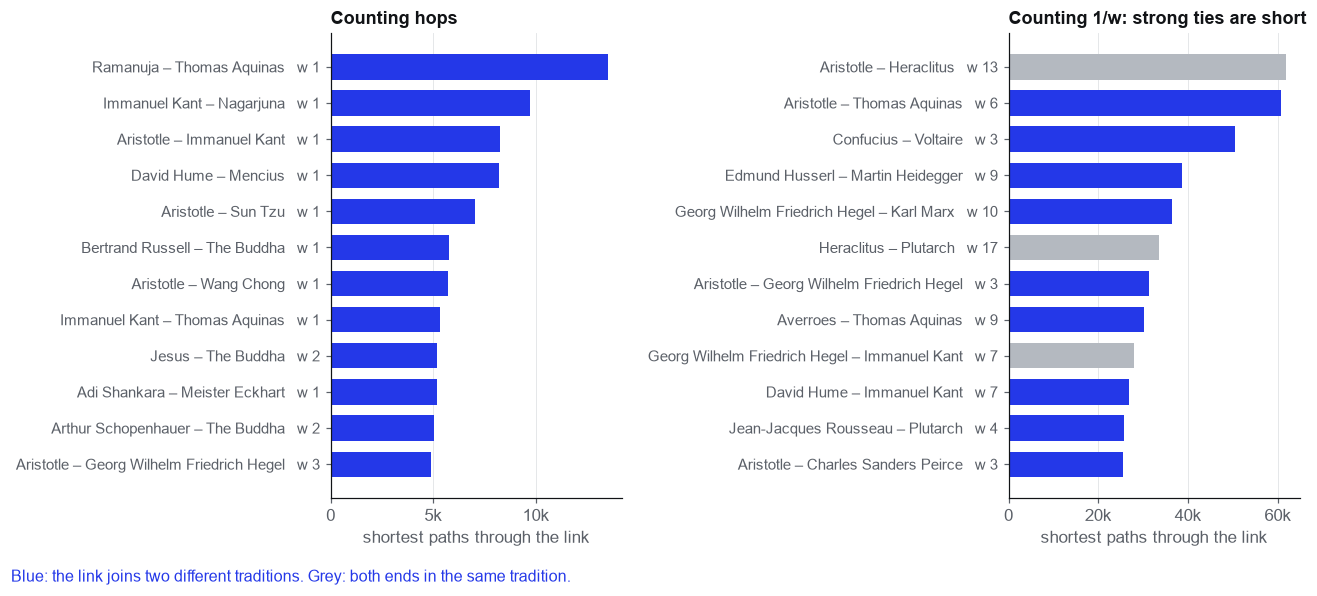

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=False)
for ax, col, title in [(axes[0], "eb", "Counting hops"), (axes[1], "ebw", "Counting 1/w: strong ties are short")]:
    T = E.nlargest(12, col).iloc[::-1]
    ax.barh(range(len(T)), T[col], color=[UM if c else PALE for c in T.cross], height=.7)
    ax.set_yticks(range(len(T)), [f"{name[u]} – {name[v]}   w {w}" for u, v, w in zip(T.u, T.v, T.w)], fontsize=9.5)
    ax.set_title(title, loc="left", fontsize=12, fontweight="bold")
    ax.set_xlabel("shortest paths through the link")
    style(ax, grid="x")
for ax in axes:
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1000:.0f}k" if v else "0"))
fig.tight_layout()
fig.text(0.01, -0.03, "Blue: the link joins two different traditions. Grey: both ends in the same tradition.", color=UM, fontsize=10.5)
save(fig, "fig3_roads")
plt.show()

**Result.** The busiest links cross between traditions: 18 of the top 20, against 35% of links overall. And they
are almost all single passing mentions (weight 1): Ramanuja – Thomas Aquinas carries the most shortest paths in the
network. Counting strong ties as short changes the picture. The busiest roads become strong ties, many inside a
tradition (Aristotle – Heraclitus), and one weight-3 link carries the road between Chinese philosophy and the rest:
Confucius – Voltaire. §7 finds the same link a second way.

## 4. How sure are we of the borders?

Louvain visits nodes in a random order, so each seed can move the borders. We run 30 more seeds and ask three
things: how much two runs agree (**normalized mutual information**, 1 = identical, 0 = independent), which
philosophers keep changing community (the average Jaccard overlap of a philosopher's community between two runs,
which needs no matching of community labels), and whether §3's finding survives when the borders move.

In [7]:
RUNS = [nxc.louvain_communities(giant, weight=None, seed=sd) for sd in RUN_SEEDS]
order = list(giant)
labels = [np.array([{v: i for i, p in enumerate(run) for v in p}[v] for v in order]) for run in RUNS]
pair_nmi = [nmi(a, b) for a, b in itertools.combinations(labels, 2)]
members = [{v: frozenset(p) for p in run for v in p} for run in RUNS]
stab = pd.Series({v: np.mean([len(a[v] & b[v]) / len(a[v] | b[v]) for a, b in itertools.combinations(members, 2)])
                  for v in order})


def cross_top20(run):
    lab = {v: i for i, p in enumerate(run) for v in p}
    return int(sum(lab[u] != lab[v] for u, v in zip(top.u, top.v)))


def w_gap(run):
    lab = {v: i for i, p in enumerate(run) for v in p}
    c = np.array([lab[u] != lab[v] for u, v in zip(E.u, E.v)])
    return E.w[~c].mean(), E.w[c].mean()


settled = stab[k[stab.index] >= 15].nsmallest(8)
gaps = np.array([w_gap(run) for run in RUNS])
STATS["stability"] = dict(runs=len(RUNS), count_range=[min(map(len, RUNS)), max(map(len, RUNS))],
                          nmi_range=[round(min(pair_nmi), 2), round(max(pair_nmi), 2)], nmi_median=round(float(np.median(pair_nmi)), 2),
                          median_keep=round(stab.median(), 2),
                          least_settled=[[name[v], int(k[v]), round(x, 2)] for v, x in settled.items()],
                          aristotle_keep=round(stab["Aristotle"], 2),
                          aristotle_with_plato=sum("Plato" in mm["Aristotle"] for mm in members),
                          aristotle_with_aquinas=sum("Thomas_Aquinas" in mm["Aristotle"] for mm in members),
                          cross_top20_range=[min(map(cross_top20, RUNS)), max(map(cross_top20, RUNS))],
                          w_inside_range=[round(float(gaps[:, 0].min()), 2), round(float(gaps[:, 0].max()), 2)],
                          w_across_range=[round(float(gaps[:, 1].min()), 2), round(float(gaps[:, 1].max()), 2)])
st = STATS["stability"]
print(f"  {st['runs']} seeds: {st['count_range'][0]}–{st['count_range'][1]} communities; NMI between runs {st['nmi_range'][0]}–{st['nmi_range'][1]} (median {st['nmi_median']})")
print(f"  a typical philosopher keeps {st['median_keep']:.0%} of their community-mates between runs; Aristotle {st['aristotle_keep']:.0%}")
print(f"  Aristotle shares a community with Plato in {st['aristotle_with_plato']} runs, with Aquinas in {st['aristotle_with_aquinas']}")
print(f"  §3 in every run: {st['cross_top20_range'][0]}–{st['cross_top20_range'][1]} of the top-20 links cross; "
      f"mean weight inside {st['w_inside_range']}, across {st['w_across_range']}")
pd.DataFrame(st["least_settled"], columns=["least settled (degree ≥ 15)", "degree", "keeps"]).set_index("least settled (degree ≥ 15)")

  30 seeds: 7–10 communities; NMI between runs 0.61–0.85 (median 0.72)
  a typical philosopher keeps 65% of their community-mates between runs; Aristotle 45%
  Aristotle shares a community with Plato in 16 runs, with Aquinas in 13
  §3 in every run: 17–18 of the top-20 links cross; mean weight inside [1.81, 1.86], across [1.45, 1.54]


,degree,keeps
least settled (degree ≥ 15),,
Alexandre Koyré,19,0.23
Emanuel Swedenborg,27,0.23
Paracelsus,21,0.25
Galileo Galilei,52,0.26
Lucretius,19,0.26
Marin Mersenne,24,0.26
Johannes Kepler,28,0.27
Giordano Bruno,30,0.27


  wrote Figures/Week4/fig4_stability.png


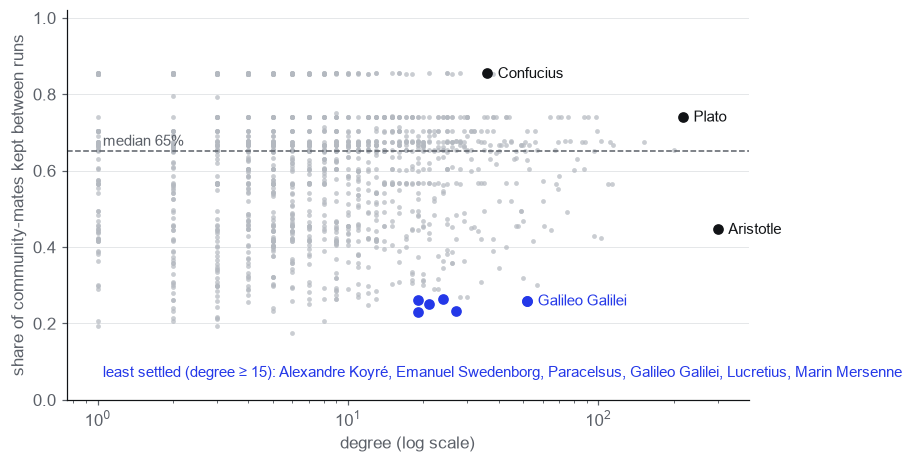

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(k[stab.index], stab, s=10, color=PALE, alpha=.7, linewidths=0)
ax.scatter(k[settled.index[:6]], stab[settled.index[:6]], s=36, color=UM, zorder=3)
for v in ["Galileo_Galilei", "Aristotle", "Plato", "Confucius"]:
    ax.scatter([k[v]], [stab[v]], s=36, color=UM if v in settled.index else INK, zorder=3)
    ax.annotate(name[v], (k[v], stab[v]), xytext=(7, -3), textcoords="offset points", fontsize=10, color=UM if v in settled.index else INK)
ax.text(1.05, .06, "least settled (degree ≥ 15): " + ", ".join(name[settled.index[:6]]), color=UM, fontsize=9.5)
ax.axhline(stab.median(), color=MID, lw=1, ls="--")
ax.text(1.05, stab.median() + .015, f"median {stab.median():.0%}", color=MID, fontsize=9.5)
ax.set(xscale="log", ylim=(0, 1.02), xlabel="degree (log scale)", ylabel="share of community-mates kept between runs")
style(ax)
save(fig, "fig4_stability")
plt.show()

**Result.** The runs agree on the large picture (NMI 0.61–0.85 between any two) and disagree at the borders. The least settled
philosophers are one historical group, the Scientific Revolution and its neighbours: they keep about a quarter of
their community-mates. §3 survives every run: the busiest links keep crossing, and links across borders stay
lighter than links inside.

## 5. What are the meeting links made of?

Each link has a **weight** $w_{ij}$, and a philosopher's **strength** is $s_i = \sum_j w_{ij}$. If traditions are held
together from inside by repeated mentions and joined to each other by passing ones, the links across borders should
be lighter.

A trap to avoid: weighted Louvain (weights for links, strengths for degrees, total weight for $m$) scores higher,
but its $Q$ answers a different question and is not comparable to the unweighted one.

  34.7% of links cross traditions but carry 30.1% of the weight
  mean weight inside 1.85, across 1.49; weight 1: 60% inside, 73% across
  weighted Louvain: 9 communities, weighted Q = 0.55 (not comparable to 0.50)


  wrote Figures/Week4/fig5_weights.png


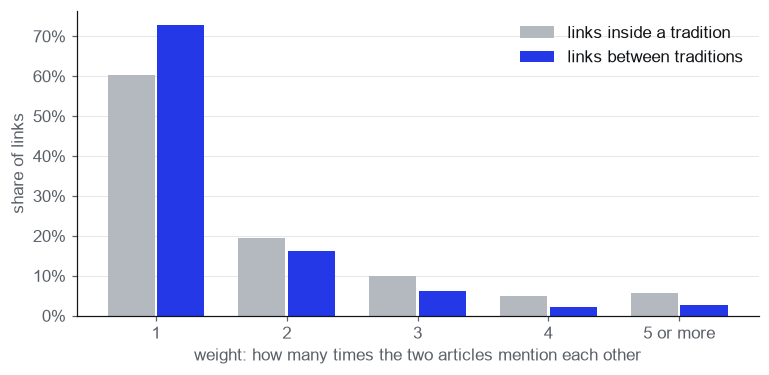

In [9]:
inside, across = E[~E.cross], E[E.cross]
wparts = nxc.louvain_communities(giant, weight="weight", seed=SEED)
bins = [1, 2, 3, 4, 5]
dist = lambda D: [float(((D.w == b) if b < 5 else (D.w >= 5)).mean()) for b in bins]
STATS["weights"] = dict(share_links_across=round(len(across) / m, 3), share_weight_across=round(across.w.sum() / E.w.sum(), 3),
                        mean_w_inside=round(inside.w.mean(), 2), mean_w_across=round(across.w.mean(), 2),
                        w1_inside=round((inside.w == 1).mean(), 2), w1_across=round((across.w == 1).mean(), 2),
                        heavy_inside=round((inside.w >= 5).mean(), 3), heavy_across=round((across.w >= 5).mean(), 3),
                        weighted_louvain=dict(count=len(wparts), Q_weighted=round(nxc.modularity(giant, wparts, weight="weight"), 2)))
wt = STATS["weights"]
print(f"  {wt['share_links_across']:.1%} of links cross traditions but carry {wt['share_weight_across']:.1%} of the weight")
print(f"  mean weight inside {wt['mean_w_inside']}, across {wt['mean_w_across']}; weight 1: {wt['w1_inside']:.0%} inside, {wt['w1_across']:.0%} across")
print(f"  weighted Louvain: {wt['weighted_louvain']['count']} communities, weighted Q = {wt['weighted_louvain']['Q_weighted']} (not comparable to {Q:.2f})")

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(bins))
ax.bar(x - .19, dist(inside), .36, color=PALE, label="links inside a tradition")
ax.bar(x + .19, dist(across), .36, color=UM, label="links between traditions")
ax.set_xticks(x, ["1", "2", "3", "4", "5 or more"])
ax.set(xlabel="weight: how many times the two articles mention each other", ylabel="share of links")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(frameon=False)
style(ax)
save(fig, "fig5_weights")
plt.show()

**Result.** The borders are sewn with weak thread. Links between traditions are a third of all links but carry less
than a third of the weight, and nearly three in four of them are a single mention.

## 6. Who stands where traditions meet?

A partition must give every philosopher one tradition. Overlapping methods do not:

- **$k$-clique communities** (Palla et al. 2005): two $k$-cliques are adjacent when they share $k-1$ nodes; a community
  is everything reachable by rolling from one to the next. We use $k = 5$, where the page finds small sharp schools.
- **Link communities** (Ahn, Bagrow & Lehmann 2010): cluster the *links* by the Jaccard overlap of their endpoints'
  inclusive neighbourhoods (single linkage, cut at the maximum partition density $D$); a philosopher inherits every
  community their links are in. We count communities of three or more links, as in SGI-4.9.

Aristotle is the test case.

In [10]:
k5 = list(nxc.k_clique_communities(giant, 5))
in_k5 = pd.Series({v: sum(v in c for c in k5) for v in giant})


def link_communities(g):
    links = [tuple(sorted(e)) for e in g.edges()]
    lid = {e: i for i, e in enumerate(links)}
    inc = {v: set(g[v]) | {v} for v in g}
    pairs = sorted(((len(inc[i] & inc[j]) / len(inc[i] | inc[j]), lid[tuple(sorted((i, c)))], lid[tuple(sorted((j, c)))])
                    for c in g for i, j in itertools.combinations(sorted(g[c]), 2)), reverse=True)
    parent, m_c, n_set = list(range(len(links))), [1] * len(links), [set(e) for e in links]

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    term = lambda mc, nc: 0.0 if nc <= 2 else mc * (mc - (nc - 1)) / ((nc - 2) * (nc - 1))
    total, best, i = 0.0, (-1, None), 0
    while i < len(pairs):                              # merge one dendrogram height at a time, track D
        sim = pairs[i][0]
        while i < len(pairs) and pairs[i][0] == sim:
            ra, rb = find(pairs[i][1]), find(pairs[i][2])
            i += 1
            if ra != rb:
                total -= term(m_c[ra], len(n_set[ra])) + term(m_c[rb], len(n_set[rb]))
                parent[rb] = ra
                m_c[ra] += m_c[rb]
                n_set[ra] |= n_set[rb]
                total += term(m_c[ra], len(n_set[ra]))
        if 2 * total / len(links) > best[0]:
            best = (2 * total / len(links), sim)
    parent = list(range(len(links)))                   # replay the merges down to the best height
    for sim, a, b in pairs:
        if sim < best[1]:
            break
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra
    groups = {}
    for x, e in enumerate(links):
        groups.setdefault(find(x), []).append(e)
    return [c for c in groups.values() if len(c) >= 3], best


lc, (D_best, sim_best) = link_communities(giant)
in_lc = pd.Series({v: 0 for v in giant}) + pd.Series(pd.Series([v for c in lc for v in {x for e in c for x in e}]).value_counts())
in_lc = in_lc.fillna(0).astype(int)
arist = pd.Series([group[comm[u]] for u in giant["Aristotle"]]).value_counts()
STATS["overlap"] = dict(aristotle_links_by_tradition={g: int(arist.get(g, 0)) for g in group},
                        aristotle_home=int(arist[group[comm["Aristotle"]]]),
                        aristotle_k5=int(in_k5["Aristotle"]), k5_count=len(k5), k5_top=[[name[v], int(c)] for v, c in in_k5.nlargest(4).items()],
                        aristotle_lc=int(in_lc["Aristotle"]), lc_count=len(lc), lc_D=round(D_best, 3),
                        lc_overlap=int((in_lc >= 2).sum()))
ov = STATS["overlap"]
print(f"  Aristotle: {ov['aristotle_home']} of his {k['Aristotle']} links stay in his own tradition; by tradition {ov['aristotle_links_by_tradition']}")
print(f"  k = 5: {ov['k5_count']} communities; most memberships {ov['k5_top']}")
print(f"  link communities: D = {ov['lc_D']}, {ov['lc_count']} of ≥ 3 links; Aristotle in {ov['aristotle_lc']}; {ov['lc_overlap']} philosophers in ≥ 2")

  Aristotle: 103 of his 300 links stay in his own tradition; by tradition {'Immanuel Kant & co.': 28, 'Thomas Aquinas & co.': 74, 'John Locke & co.': 22, 'Aristotle & co.': 103, 'Bertrand Russell & co.': 18, 'René Descartes & co.': 29, 'The Buddha & co.': 0, 'Avicenna & co.': 24, 'Confucius & co.': 2}
  k = 5: 40 communities; most memberships [['Aristotle', 6], ['Augustine of Hippo', 5], ['Friedrich Nietzsche', 5], ['Thomas Aquinas', 5]]
  link communities: D = 0.054, 444 of ≥ 3 links; Aristotle in 23; 693 philosophers in ≥ 2


  wrote Figures/Week4/fig6_aristotle.png


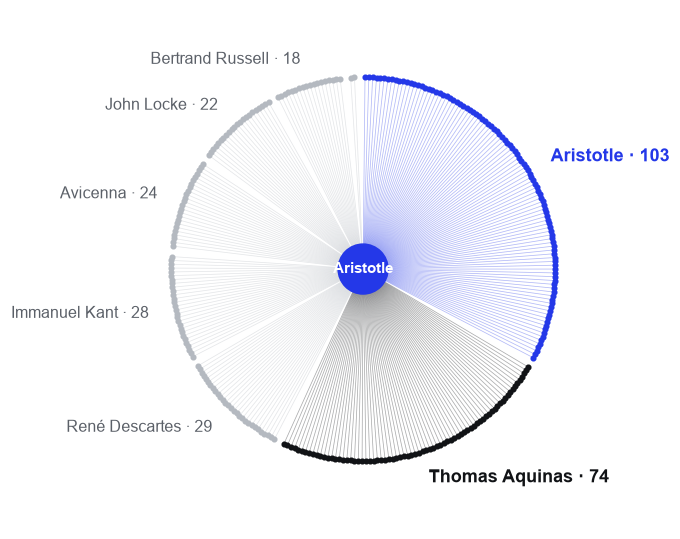

In [11]:
fig, ax = plt.subplots(figsize=(7.2, 7.2))
counts = [(g, c) for g, c in sorted(ov["aristotle_links_by_tradition"].items(), key=lambda x: -x[1]) if c > 0]
home, schol = group[comm["Aristotle"]], group[comm["Thomas_Aquinas"]]
col = lambda g: UM if g == home else (INK if g == schol else PALE)
gap = 0.035
span, a0 = 2 * np.pi - gap * len(counts), np.pi / 2
for g, c in counts:
    t = a0 - span * (np.arange(c) + .5) / 300
    ax.plot(np.vstack([np.zeros(c), np.cos(t)]), np.vstack([np.zeros(c), np.sin(t)]), color=col(g), lw=.5, alpha=.35)
    ax.scatter(np.cos(t), np.sin(t), s=9, color=col(g), zorder=3)
    tm = a0 - span * c / 600
    if c >= 5:
        ax.text(1.14 * np.cos(tm), 1.14 * np.sin(tm), f"{g.replace(' & co.', '')} · {c}", ha="left" if np.cos(tm) > .2 else ("right" if np.cos(tm) < -.2 else "center"),
                va="center", fontsize=12 if g in (home, schol) else 10.5, fontweight="bold" if g in (home, schol) else "normal",
                color=UM if g == home else (INK if g == schol else MID))
    a0 -= span * c / 300 + gap
ax.add_patch(plt.Circle((0, 0), .13, color=UM, zorder=4))
ax.text(0, 0, "Aristotle", ha="center", va="center", color="white", fontsize=10, fontweight="bold", zorder=5)
ax.set(xlim=(-1.6, 1.6), ylim=(-1.35, 1.35), aspect="equal")
ax.axis("off")
save(fig, "fig6_aristotle")
plt.show()

**Result.** Aristotle is the clearest person standing where traditions meet. Only about a third of his links stay
in his own tradition, the scholastics take a quarter, and Louvain splits its runs between putting him with Plato and
with Aquinas. The overlapping methods put him in more communities than anyone.

## 7. Can a drawing show the meeting points?

Drawn whole, 9,139 links are a hairball. A **global threshold** keeps links with $w \ge \theta$. The **disparity
filter** (Serrano, Boguñá & Vespignani 2009) asks each philosopher separately: with $p_{ij} = w_{ij}/s_i$, if $i$'s
strength were spread uniformly at random over its $k_i$ links, a link would take at least this share with probability
$(1-p_{ij})^{k_i-1}$. The link is kept if that is below $\alpha$ at either end.

We compare the two on who they keep, check what happens to the links that cross between traditions, and turn $\alpha$
like a dial to see when each tradition joins the connected skeleton. The drawing follows the page's five rules:
backbone first, layout of the backbone, colour by communities found on the full network, size by strength, label the
important nodes.

In [12]:
for end in "uv":
    E[f"alpha_{end}"] = (1 - E.w / E[end].map(s)) ** (E[end].map(k) - 1)
E["alpha_min"] = E[["alpha_u", "alpha_v"]].min(axis=1)


def skeleton(kept):
    B = nx.Graph(kept[["u", "v"]].itertuples(index=False))
    return B, max(nx.connected_components(B), key=len)


filters = {"threshold w ≥ 3": E[E.w >= 3]} | {f"disparity α = {a}": E[E.alpha_min < a] for a in (0.1, 0.2, 0.3)}
rows = []
for label, kept in filters.items():
    B, gc = skeleton(kept)
    rows.append(dict(filter=label, links=len(kept), attached=B.number_of_nodes(), connected=len(gc),
                     crossing=round(kept.cross.mean(), 3), busiest_20_kept=int(top.index.isin(kept.index).sum())))
table = pd.DataFrame(rows).set_index("filter")
att = lambda kept: set(kept.u) | set(kept.v)
f02, t3 = filters["disparity α = 0.2"], filters["threshold w ≥ 3"]
STATS["skeleton"] = dict(table=table.reset_index().to_dict("records"),
                         only_filter=len(att(f02) - att(t3)), only_threshold=len(att(t3) - att(f02)),
                         min_alpha_w1=round(E[E.w == 1].alpha_min.min(), 3))
print(f"  attached only by α = 0.2: {STATS['skeleton']['only_filter']}; only by w ≥ 3: {STATS['skeleton']['only_threshold']}")
print(f"  a weight-1 link needs α > {STATS['skeleton']['min_alpha_w1']} to survive at either end")
table

  attached only by α = 0.2: 112; only by w ≥ 3: 25
  a weight-1 link needs α > 0.381 to survive at either end


,links,attached,connected,crossing,busiest_20_kept
filter,,,,,
threshold w ≥ 3,1572,863,747,0.224,2
disparity α = 0.1,649,607,419,0.217,0
disparity α = 0.2,1540,950,816,0.244,2
disparity α = 0.3,2549,1111,1052,0.262,4


In [13]:
# the dial: loosen α in steps of 0.02 and record who is inside the connected skeleton
DIAL = []
for a in np.round(np.arange(0.02, 0.501, 0.02), 2):
    kept = E[E.alpha_min < a]
    B, gc = skeleton(kept)
    DIAL.append(dict(alpha=float(a), links=len(kept), attached=B.number_of_nodes(), connected=len(gc),
                     share=[round(len(p & gc) / len(p), 3) for p in parts]))

# the bridges: admit links in order of α and note each one that joins a block of ≥ 15 philosophers,
# mostly from one tradition, to the growing connected skeleton
H, bridges = nx.Graph(), []
for u, v, w, a_u, a_v, a in E.sort_values("alpha_min")[["u", "v", "w", "alpha_u", "alpha_v", "alpha_min"]].itertuples(index=False):
    if a >= 0.5:
        break
    cu = nx.node_connected_component(H, u) if u in H else {u}
    cv = nx.node_connected_component(H, v) if v in H else {v}
    if v not in cu and min(len(cu), len(cv)) >= 15:
        small = min(cu, cv, key=len)
        vc = pd.Series([comm[x] for x in small]).value_counts()
        trad, n_trad = vc.index[0], vc.iloc[0]
        if n_trad / len(small) >= .8:
            bridges.append(dict(alpha=round(a, 4), link=[name[u], name[v]], w=int(w), block=len(small), tradition=group[trad],
                                ends={name[u]: [int(k[u]), int(s[u]), round(a_u, 3)], name[v]: [int(k[v]), int(s[v]), round(a_v, 3)]},
                                ebw_rank=int(E.ebw.rank(ascending=False, method="min")[(E.u == u) & (E.v == v)].iloc[0])))
    H.add_edge(u, v)
first_half = {group[i]: next(d["alpha"] for d in DIAL if d["share"][i] >= .5) for i in range(len(parts))}
STATS["dial"] = dict(steps=DIAL, bridges=bridges, first_half=first_half, traditions=group)
for b in bridges:
    print(f"  α {b['alpha']:.3f}: {' – '.join(b['link'])} (w {b['w']}) joins {b['block']} philosophers of {b['tradition']}; "
          f"per end {b['ends']}; rank #{b['ebw_rank']} by weighted edge betweenness")
print(f"  half of each tradition connected first at α = {first_half}")

  α 0.170: Confucius – Voltaire (w 3) joins 22 philosophers of Confucius & co.; per end {'Confucius': [36, 65, 0.191], 'Voltaire': [77, 130, 0.17]}; rank #3 by weighted edge betweenness
  α 0.297: Gaudapada – The Buddha (w 2) joins 24 philosophers of The Buddha & co.; per end {'Gaudapada': [8, 14, 0.34], 'The Buddha': [38, 62, 0.297]}; rank #73 by weighted edge betweenness
  half of each tradition connected first at α = {'Immanuel Kant & co.': 0.14, 'Thomas Aquinas & co.': 0.2, 'John Locke & co.': 0.16, 'Aristotle & co.': 0.12, 'Bertrand Russell & co.': 0.18, 'René Descartes & co.': 0.2, 'The Buddha & co.': 0.3, 'Avicenna & co.': 0.18, 'Confucius & co.': 0.22}


  wrote Figures/Week4/fig7_dial.png


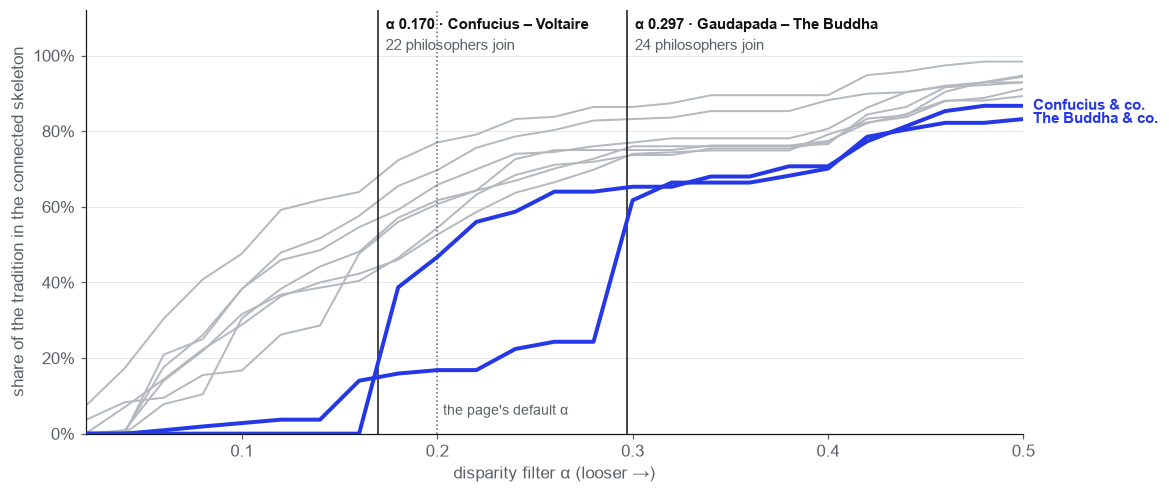

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
al = [d["alpha"] for d in DIAL]
focus = [i for i, g in enumerate(group) if g.startswith(("Confucius", "The Buddha"))]
for i in range(len(parts)):
    ax.plot(al, [d["share"][i] for d in DIAL], color=UM if i in focus else PALE, lw=2.6 if i in focus else 1.3, zorder=3 if i in focus else 2)
for i in focus:
    ax.text(0.505, DIAL[-1]["share"][i], group[i], color=UM, fontsize=10, fontweight="bold", va="center")
for b in bridges:
    ax.axvline(b["alpha"], color=INK, lw=1)
    ax.text(b["alpha"] + .004, 1.07, f"α {b['alpha']:.3f} · {' – '.join(b['link'])}", fontsize=10, fontweight="bold")
    ax.text(b["alpha"] + .004, 1.015, f"{b['block']} philosophers join", fontsize=9.5, color=MID)
ax.axvline(0.2, color=MID, lw=1, ls=":")
ax.text(0.203, 0.05, "the page's default α", color=MID, fontsize=9, ha="left")
ax.set(xlim=(0.02, 0.5), ylim=(0, 1.12), xlabel="disparity filter α (looser →)", ylabel="share of the tradition in the connected skeleton")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}" if v <= 1 else ""))
style(ax)
save(fig, "fig7_dial")
plt.show()

  wrote Figures/Week4/fig1_map.png


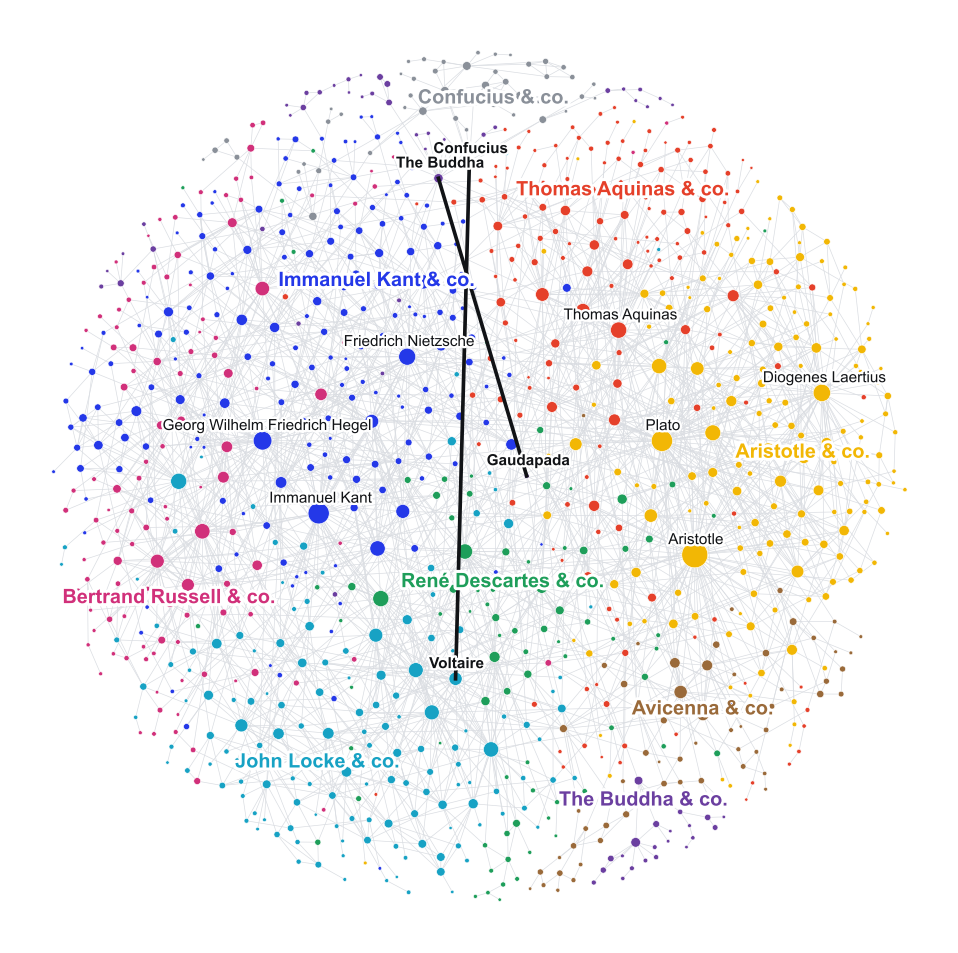

  wrote Figures/Week4/fig8_roads.png


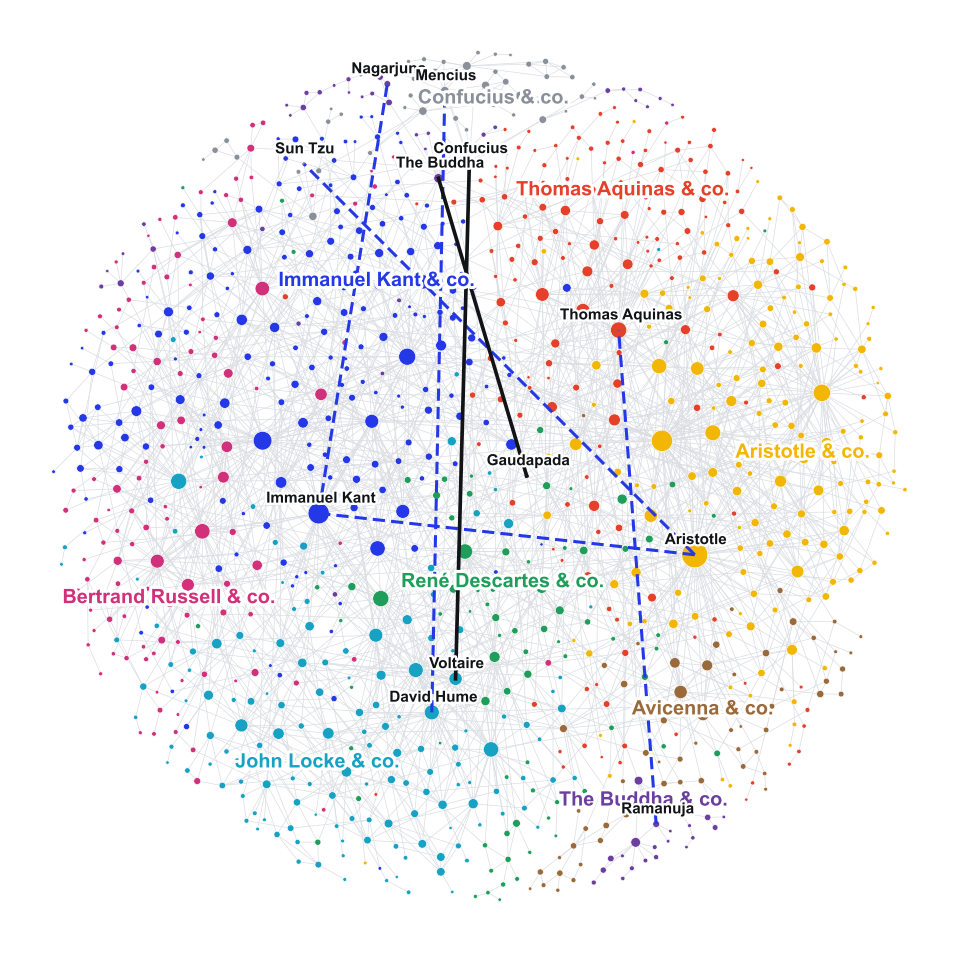

  α = 0.3: 2,549 links; 1,052 drawn; 263 with no link, 59 in 27 small pieces; busiest 5 roads drawn on top: 5


In [15]:
def backbone_layout(B, seed=11):
    # the giant component of the skeleton only (rule 2: lay out the backbone), ForceAtlas2 run to convergence
    comps = sorted(nx.connected_components(B), key=len, reverse=True)
    pos = nx.forceatlas2_layout(B.subgraph(comps[0]), seed=seed, max_iter=2000, scaling_ratio=5, strong_gravity=True)
    return nx.rescale_layout_dict(pos, 1), comps


def draw_map(roads=False):
    fig, ax = plt.subplots(figsize=(11, 11))
    Bg = B3.subgraph(gc3)
    for u, v in Bg.edges():
        ax.plot(*zip(pos[u], pos[v]), color="#DADDE2", lw=.45, zorder=1)
    order = sorted(gc3, key=s.get)
    ax.scatter([pos[v][0] for v in order], [pos[v][1] for v in order], s=[3 + .55 * s[v] for v in order],
               c=[PAL[comm[v]] for v in order], edgecolors="white", linewidths=.4, zorder=2)
    for i, p in enumerate(parts):                          # label each tradition where it is densest (not colour alone)
        xy = np.array([pos[v] for v in p & gc3])
        if len(xy) >= 20:
            near = (np.linalg.norm(xy[:, None] - xy[None], axis=2) < .22).sum(1)
            ax.text(*xy[near.argmax()], group[i], fontsize=13, fontweight="bold", color=PAL[i], ha="center", zorder=5,
                    path_effects=[plt.matplotlib.patheffects.withStroke(linewidth=4, foreground="white")])
    for b in bridges:
        u, v = [nid[x] for x in b["link"]]
        ax.plot(*zip(pos[u], pos[v]), color=INK, lw=2.4, zorder=4)
    halo = [plt.matplotlib.patheffects.withStroke(linewidth=3, foreground="white")]
    ends = {nid[x] for b in bridges for x in b["link"]}
    if roads:                                              # the busiest roads, which no backbone keeps, as their own layer
        drawn = 0
        for r in top.head(5).itertuples():
            if r.u in pos and r.v in pos:
                ax.plot(*zip(pos[r.u], pos[r.v]), color=UM, lw=2, ls=(0, (4, 2)), zorder=3)
                ends |= {r.u, r.v}
                drawn += 1
        STATS["map"]["roads_drawn"] = drawn
        labelled = ends
    else:
        labelled = set(s.nlargest(7).index) | ends
    for v in labelled:
        ax.annotate(name[v], pos[v], xytext=(0, 7), textcoords="offset points", ha="center", fontsize=10, zorder=6,
                    fontweight="bold" if v in ends else "normal", path_effects=halo)
    ax.set_aspect("equal")
    ax.axis("off")
    return fig


import matplotlib.patheffects  # noqa: E402  (used by draw_map)
nid = {v: u for u, v in name.items()}
B3, gc3 = skeleton(E[E.alpha_min < ALPHA_DRAW])
pos, comps3 = backbone_layout(B3)
STATS["map"] = dict(alpha=ALPHA_DRAW, links=int((E.alpha_min < ALPHA_DRAW).sum()), connected=len(gc3),
                    no_link=n - B3.number_of_nodes(), small_pieces=len(comps3) - 1,
                    in_small_pieces=B3.number_of_nodes() - len(gc3))
save(draw_map(), "fig1_map")
plt.show()
save(draw_map(roads=True), "fig8_roads")
plt.show()
print(f"  α = {ALPHA_DRAW}: {STATS['map']['links']:,} links; {STATS['map']['connected']:,} drawn; {STATS['map']['no_link']} with no link, "
      f"{STATS['map']['in_small_pieces']} in {STATS['map']['small_pieces']} small pieces; busiest 5 roads drawn on top: {STATS['map']['roads_drawn']}")

**Result.** The disparity filter and the threshold keep about the same number of links but different people, and
neither keeps the busiest roads: a weight-1 link cannot pass the test at any $\alpha$ we would draw with. Turning the
dial shows the traditions joining one at a time, and two links carry whole traditions in. One of them, Confucius –
Voltaire, is the same link that weighted edge betweenness ranked among the busiest in §3. At the page's default
$\alpha = 0.2$ most of Indian philosophy is still outside the connected skeleton, so we draw $\alpha = 0.3$.

## 8. 🔬 Are the key links what we say they are?

Every claim above treats a link as a connection between two traditions. A link is one article naming another, so we
read the sentence behind each of the six links the story leans on: the four busiest roads and the two bridges. The
edge file says which article links to which, so the code fetches the linking article's plain text from the Wikipedia
API and prints the first sentence that names the other philosopher.

In [16]:
HEAD = {"User-Agent": "DTU-02805-coursework/1.0 (https://sunelehmann.com/socialgraphs2026-web/; student notebook)"}
directed = set(zip(edges.source, edges.target))
text_cache = {}


def text_of(title):   # one polite request per article; back off on HTTP 429
    if title not in text_cache:
        for attempt in range(6):
            r = requests.get("https://en.wikipedia.org/w/api.php", headers=HEAD, timeout=30,
                             params={"action": "query", "prop": "extracts", "explaintext": 1, "titles": title,
                                     "format": "json", "formatversion": 2, "redirects": 1})
            if r.status_code != 429:
                break
            time.sleep(int(r.headers.get("Retry-After", 10 * 2 ** attempt)))
        r.raise_for_status()
        text_cache[title] = r.json()["query"]["pages"][0].get("extract", "")
        time.sleep(1)
    return text_cache[title]


def sentence(src, dst):
    full = re.sub(r"\s*\(.*\)", "", name[dst])
    for key_ in dict.fromkeys([full, full.split()[-1]]):
        for sent in re.split(r"(?<=[.!?])\s+", text_of(unquote(nodes.loc[src, "url"].rsplit("/", 1)[1]).replace("_", " "))):
            if key_ in sent:
                return sent.strip()[:320]
    return "(name not found in the plain text)"


CHECK = [tuple(x["link"]) for x in STATS["roads"]["top"][:4]] + [tuple(b["link"]) for b in bridges]
rows = []
for a_, b_ in CHECK:
    u, v = nid[a_], nid[b_]
    for src, dst in [(u, v), (v, u)]:
        if (src, dst) in directed:
            rows.append({"link": f"{a_} – {b_}", "in the article of": name[src], "the sentence": sentence(src, dst)})
evidence = pd.DataFrame(rows).set_index(["link", "in the article of"])
with pd.option_context("display.max_colwidth", 330):
    display(evidence)

the sentence
link                      in the article of                                                                                                                                                                                                                                                                                                                                      
Ramanuja – Thomas Aquinas Ramanuja                                                                                                                                                                                                    Modern scholars have compared the importance of Ramanuja in Hinduism to that of scholar Thomas Aquinas (1225–1274) in Western Christianity.
Immanuel Kant – Nagarjuna Nagarjuna              While some (Murti, 1955) have interpreted this by positing Nāgārjuna as a neo-Kantian and thus making ultimate truth a metaphysical noumenon or an "ineffable ultimate that transcends the capacities of discursive reason", the more traditional and standard interpretation, defended by modern scholars like Westerhoff, Mark
Aristotle – Immanuel Kant Aristotle                                                                                                                                                                                                                                            Kant even stated in the Critique of Pure Reason that with Aristotle, logic reached its completion.
David Hume – Mencius      David Hume                                                                                                                                                                                                                                                                                                           (name not found in the plain text)
Confucius – Voltaire      Confucius               === In the West ===\nThe influence of Confucius has been observed on multiple Western thinkers, including Niels Bohr, Benjamin Franklin, Allen Ginsberg, Thomas Jefferson, Gottfried Wilhelm Leibniz, Robert Cummings Neville, Alexander Pope, Ezra Pound, François Quesnay, Friedrich Schiller, Voltaire, and Christian Wolff.
                          Voltaire                                                                                                                                                                                    === Confucianism ===\n\nWorks attributed to Confucius were translated into European languages through the agency of Jesuit missionaries stationed in China.
Gaudapada – The Buddha    Gaudapada          The last Karikas of the Chapter Four add, as translated by Karl Potter, "this the Buddhas understand, the Buddha instructs us that consciousness does not reach the dharmas, yet the Buddha said nothing about either consciousness or dharmas!"\n\n\n=== Gaudapada's Soteriology ===\nAccording to Gaudapada, liberation is the rea

One link has no sentence in the running text. The plain-text extract leaves out lists and boxes, so for those the
code looks in the article's wiki source and reports the section the link sits in.

In [17]:
def section_of(src, dst):
    r = requests.get("https://en.wikipedia.org/w/api.php", headers=HEAD, timeout=30,
                     params={"action": "parse", "page": unquote(nodes.loc[src, "url"].rsplit("/", 1)[1]).replace("_", " "),
                             "prop": "wikitext", "format": "json", "formatversion": 2, "redirects": 1}).json()
    wt = r["parse"]["wikitext"]
    hit = re.search(r"\[\[" + re.escape(unquote(nodes.loc[dst, "url"].rsplit("/", 1)[1]).replace("_", " ")) + r"[\]|]", wt)
    if not hit:
        return "not found in the wiki source either"
    heads = re.findall(r"^==+\s*(.*?)\s*==+\s*$", wt[:hit.start()], flags=re.M)
    return f"in the section '{heads[-1] if heads else 'lead'}'"


for (link, src), row in evidence.iterrows():
    if row["the sentence"].startswith("(name not found"):
        a_, b_ = link.split(" – ")
        dst = nid[b_] if a_ == src else nid[a_]
        print(f"  {link}: {section_of(nid[src], dst)} of {src}'s article")

  David Hume – Mencius: in the section 'See also' of David Hume's article


**Reading them.** The verdicts below were written after reading each sentence and the section around it.

In [18]:
VERDICT = {  # link: (what the link records, why)
    "Ramanuja – Thomas Aquinas": ("a modern comparison", "scholars compare Ramanuja's importance in Hinduism to Aquinas's in Christianity; the two never met in any text"),
    "Immanuel Kant – Nagarjuna": ("a modern comparison", "a 20th-century reading (Murti) of Nagarjuna as a neo-Kantian, and the standard view that rejects it"),
    "Aristotle – Immanuel Kant": ("engagement", "Kant wrote that with Aristotle, logic reached its completion"),
    "David Hume – Mencius": ("a cross-reference", "a bare entry in the See also list of Hume's article"),
    "Confucius – Voltaire": ("engagement", "Voltaire is among the Western thinkers Confucius influenced; Voltaire's article has a section on Confucianism"),
    "Gaudapada – The Buddha": ("engagement", "Gaudapada's Karika quotes the Buddha on consciousness and the dharmas"),
}
assert set(VERDICT) == {f"{a} – {b}" for a, b in CHECK}, "the checked links changed: re-read them before writing verdicts"
STATS["validation"] = [[link, *VERDICT[link]] for link in VERDICT]
with pd.option_context("display.max_colwidth", 200):
    display(pd.DataFrame([{"link": l, "records": v[0], "why": v[1]} for l, v in VERDICT.items()]).set_index("link"))

,records,why
link,,
Ramanuja – Thomas Aquinas,a modern comparison,scholars compare Ramanuja's importance in Hinduism to Aquinas's in Christianity; the two never met in any text
Immanuel Kant – Nagarjuna,a modern comparison,"a 20th-century reading (Murti) of Nagarjuna as a neo-Kantian, and the standard view that rejects it"
Aristotle – Immanuel Kant,engagement,"Kant wrote that with Aristotle, logic reached its completion"
David Hume – Mencius,a cross-reference,a bare entry in the See also list of Hume's article
Confucius – Voltaire,engagement,Voltaire is among the Western thinkers Confucius influenced; Voltaire's article has a section on Confucianism
Gaudapada – The Buddha,engagement,Gaudapada's Karika quotes the Buddha on consciousness and the dharmas


**Result.** The four busiest roads by hop count include only one real engagement, Aristotle–Kant. The other three
are how modern writers relate traditions: a comparison, an interpretation and a See-also entry. The two bridges the
weights and the backbone found, Confucius–Voltaire and Gaudapada–The Buddha, record real engagement. So the short
paths between East and West run through analogies drawn by modern writers, and the strong ties between them run
through what the philosophers actually read. That is the difference between counting hops and counting strength.

**What this check cannot show.** Six links out of 9,139, chosen because the story leans on them, not at random. The
evidence comes from the same Wikipedia articles that created the links, so it tells us what the links *mean*, not
whether the history is right. The verdicts are our reading.

## 9. What we found

**Strong ties build the traditions; weak ties join them.** The nine traditions are real ($Q = 0.503$ against $0.222$
for shuffles). The links between them are a third of all links but carry less weight, and nearly three in four are a
single mention. The busiest links in the network cross between traditions, and most are weight 1.

**The busiest roads are mostly analogies.** Ramanuja – Thomas Aquinas carries the most shortest paths of any link, and
it records a modern comparison. Count strong ties as short and the roads change: the East–West road becomes
Confucius – Voltaire, a link that records real influence.

**The borders move, and the same philosophers sit on them.** Across 30 runs the Scientific Revolution keeps about a
quarter of its community-mates, and Aristotle splits his runs between Plato (16) and Aquinas (13); the overlapping
methods put him in more communities than anyone.

**No backbone keeps the weak ties.** A weight-1 link cannot pass the disparity test below $\alpha = 0.38$. The filter
keeps different people than a threshold (112 against 25), and it finds the two bridges: Confucius – Voltaire again,
and Gaudapada – The Buddha. We draw $\alpha = 0.3$, because at 0.2 most of Indian philosophy is outside the skeleton.

**Choices we made.**

- *Louvain seed 0, unweighted, named after the highest-degree member.* The names are our labels. §4 shows what moves with the seed.
- *20 degree-preserving shuffles, 10 m swaps each,* as the null for $Q$ (week 2's null, nothing else from earlier weeks).
- *Edge betweenness by hops, with weighted distance ($1/w$) as the check;* one pass, not a full Girvan–Newman run.
- *$k = 5$ for clique percolation; link communities cut at the maximum partition density, counting communities of ≥ 3 links.*
- *$\alpha = 0.3$ for the drawing;* the dial in the post shows every other choice.

**What we cannot conclude.** That the traditions are the "true" schools: the partition agrees with the century lists
at an NMI of only about 0.4 (SGI-4.5), and the names are ours. That a link is an influence: §8 shows it can be a
comparison. That the busiest roads matter historically: shortest paths are a property of the article graph.

## 10. Every number, pinned

`stats.json` is the single source for the post. The check pins the headline numbers, so a change in the data, the
code or a library version fails loudly instead of leaving stale prose on the site. It also checks that the dial data
embedded in the post is identical to `STATS["dial"]`.

In [19]:
Path("stats.json").write_text(json.dumps(STATS, indent=2, ensure_ascii=False))
print(f"  wrote stats.json: {len(STATS)} entries")

EXPECTED = {("n",): 1374, ("m",): 9139, ("traditions", "count"): 9, ("traditions", "Q"): 0.503,
            ("traditions", "null_mean"): 0.222, ("traditions", "z"): 136, ("traditions", "greedy_count"): 15,
            ("traditions", "greedy_Q"): 0.416, ("roads", "cross_top20"): 18, ("roads", "w1_top20"): 16,
            ("roads", "cv_rank_weighted"): 3, ("stability", "count_range"): [7, 10], ("stability", "median_keep"): 0.65,
            ("stability", "aristotle_with_plato"): 16, ("stability", "aristotle_with_aquinas"): 13,
            ("weights", "share_links_across"): 0.347, ("weights", "share_weight_across"): 0.301,
            ("weights", "w1_inside"): 0.6, ("weights", "w1_across"): 0.73, ("overlap", "aristotle_home"): 103,
            ("overlap", "aristotle_k5"): 6, ("overlap", "aristotle_lc"): 23, ("skeleton", "only_filter"): 112,
            ("skeleton", "only_threshold"): 25, ("map", "connected"): 1052}


def get(keys):
    value = STATS
    for key_ in keys:
        value = value[key_]
    return value


bad = [key_ for key_, want in EXPECTED.items() if get(key_) != want]
for key_, want in EXPECTED.items():
    print(f"    {'.'.join(map(str, key_)):<34}{str(get(key_)):>10}   expected {str(want):>10}   {'ok' if get(key_) == want else 'MISMATCH'}")
print(f"    bridges: {[(b['link'], b['alpha']) for b in STATS['dial']['bridges']]}")
assert not bad, f"stats drifted: {bad}"
assert [b["link"] for b in STATS["dial"]["bridges"]] == [["Confucius", "Voltaire"], ["Gaudapada", "The Buddha"]]

post = Path("../../posts/week4/index.html").read_text()
embedded = json.loads(re.search(r'<script type="application/json" id="dial-data">(.*?)</script>', post, re.S).group(1))
print(f"\n    post's embedded dial data matches STATS: {embedded == STATS['dial']}")
assert embedded == STATS["dial"]

  wrote stats.json: 17 entries
    n                                       1374   expected       1374   ok
    m                                       9139   expected       9139   ok
    traditions.count                           9   expected          9   ok
    traditions.Q                           0.503   expected      0.503   ok
    traditions.null_mean                   0.222   expected      0.222   ok
    traditions.z                             136   expected        136   ok
    traditions.greedy_count                   15   expected         15   ok
    traditions.greedy_Q                    0.416   expected      0.416   ok
    roads.cross_top20                         18   expected         18   ok
    roads.w1_top20                            16   expected         16   ok
    roads.cv_rank_weighted                     3   expected          3   ok
    stability.count_range                [7, 10]   expected    [7, 10]   ok
    stability.median_keep                   0.65   expect